# 03 — Análise do Modelo (Model x Baselines)

Carrega os resultados já calculados por `src/run_evaluation.py` (teste
temporal walk-forward, últimas 8 semanas conhecidas) e analisa onde o
modelo acerta e onde ele falha — sem esconder nada.

In [1]:
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from config import DATA_RAW_DIR, RESULTS_DIR

summary = pd.read_csv(RESULTS_DIR / "onestep_model_vs_baselines.csv")
by_category = pd.read_csv(RESULTS_DIR / "onestep_by_category.csv")
by_product = pd.read_csv(RESULTS_DIR / "onestep_by_product.csv")
products = pd.read_csv(DATA_RAW_DIR / "products.csv")

summary.sort_values("wape")

,mae,wape,bias,n_obs,method
0,5.712500,0.275633,0.462500,240,model
1,5.733333,0.276639,0.375000,240,moving_average_4
2,7.125000,0.343788,0.041667,240,naive
3,7.300000,0.352232,1.000000,240,seasonal_52


## Modelo x baselines (WAPE — menor é melhor)

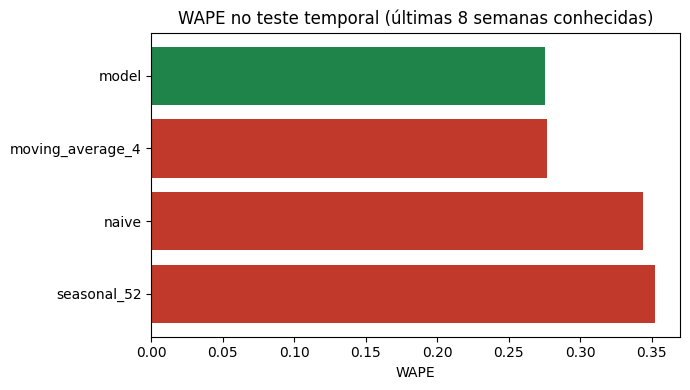

Método com menor WAPE: model (WAPE=0.2756)


In [2]:
s = summary.sort_values("wape", ascending=False)
colors = ["#1e8449" if m == "model" else "#c0392b" for m in s["method"]]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(s["method"], s["wape"], color=colors)
ax.set_title("WAPE no teste temporal (últimas 8 semanas conhecidas)")
ax.set_xlabel("WAPE")
plt.tight_layout()
plt.show()

winner = summary.sort_values("wape").iloc[0]
print(f"Método com menor WAPE: {winner['method']} (WAPE={winner['wape']:.4f})")

**Leitura honesta:** a diferença entre o modelo e a melhor baseline
(média móvel de 4 semanas) é pequena. Isso significa que boa parte do
sinal previsível já é capturada por um método simples — o ganho do
Machine Learning aqui é real, mas modesto.

## Erro por categoria

In [3]:
by_category.sort_values('wape', ascending=False)

,mae,wape,bias,n_obs,category
0,4.458333,0.504717,1.291667,48,ABRASIVOS
1,4.812500,0.312162,-0.562500,48,CORTE E USINAGEM
2,7.354167,0.295151,-0.104167,48,EPI_CONSUMIVEIS
3,6.166667,0.259422,1.583333,48,SOLDAGEM
4,5.770833,0.188052,0.104167,48,ELETRICA_BATERIAS


## Produtos mais difíceis de prever (maior WAPE)

In [4]:
hardest = by_product.merge(products[["product_id", "product_name", "criticality"]], on="product_id")
hardest.sort_values("wape", ascending=False).head(10)[
    ["product_id", "product_name", "criticality", "mae", "wape", "bias"]
]

,product_id,product_name,criticality,mae,wape,bias
0,MAT007,"Eletrodo Revestido 3,25mm",HIGH,2.500,6.666667,2.500
1,MAT012,"Eletrodo Revestido 3,25mm (Lote 2)",HIGH,7.750,2.214286,4.500
2,MAT001,"Disco de Corte 4,5 pol",HIGH,8.625,1.568182,1.125
3,MAT006,Rebolo de Bancada,HIGH,5.500,1.257143,2.000
4,MAT014,Lâmina de Serra Fita,MEDIUM,2.375,1.000000,1.375
5,MAT023,Lâmpada de Sinalização Industrial,HIGH,6.625,0.841270,1.125
6,MAT008,Arame de Solda MIG,LOW,5.500,0.698413,0.000
7,MAT026,Óculos de Segurança Incolor,LOW,3.250,0.509804,0.250
8,MAT003,"Disco Flap 4,5 pol",MEDIUM,1.625,0.481481,-0.375
9,MAT004,Lixa Grão 80,HIGH,2.500,0.434783,1.500


## Onde o modelo falha (limitação documentada)

Os piores WAPEs se concentram em produtos de baixo giro/intermitentes —
onde poucas unidades de erro absoluto já representam um percentual grande
sobre um volume real pequeno. Isso é esperado e está documentado em
`docs/LIMITATIONS.md` e `docs/MODEL_CARD.md`, não foi escondido nem
"corrigido" ajustando os dados ou o teste.

## Viés: o modelo tende a superestimar ou subestimar?

In [5]:
model_bias = summary[summary["method"] == "model"]["bias"].values[0]
direction = "superestimar" if model_bias > 0 else "subestimar"
print(f"Viés do modelo no teste: {model_bias:+.3f} unidades/semana em média")
print(f"Interpretação: o modelo tende a {direction} ligeiramente a demanda.")

Viés do modelo no teste: +0.463 unidades/semana em média
Interpretação: o modelo tende a superestimar ligeiramente a demanda.
